# Phase 2: Feature Engineering & Selection
## Predicting Hardware End-of-Life

This notebook performs:
1. Engineering of synthetic features: `Stress_Index`, `Duty_Cycle`, `Peak_Excursion`.
2. Derivation of additional features: `Thermal_RateOfChange`, `Rolling_Max_Temp_24h`, `Cumulative_Thermal_Stress`.
3. Feature importance ranking using Pearson correlation, Random Forest, and SHAP.
4. Outputting a ranked predictor metric table.
5. Saving the final feature-engineered dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11, 
                     'xtick.labelsize': 10, 'ytick.labelsize': 10, 
                     'figure.dpi': 300, 'savefig.dpi': 300})


In [2]:
# Load Cleaned Dataset 1
df = pd.read_csv('../data/processed/dataset1_clean.csv')

# Ensure chronological order for rolling features
df = df.sort_values(by=['Device_ID', 'Uptime_Cycles'])
print("Shape before engineering:", df.shape)


Shape before engineering: (3000, 6)


In [3]:
# 1. Stress_Index
df['Stress_Index'] = df['Workload_Ratio'] * df['Thermal_Log']

# 2. Duty_Cycle (Proxy: Assume total lifetime of device for downtime calculation, or use Uptime/1 if no downtime data)
# Assuming constant monitoring where downtime is rare; we'll use a simplified duty cycle for now.
# In a real scenario, we'd need timestamps to calculate downtime. We'll use a placeholder ratio for demonstration.
df['Duty_Cycle'] = df['Uptime_Cycles'] / (df['Uptime_Cycles'].max()) # Simplification

# 3. Peak_Excursion
# Count of times Thermal_Log > 85 for a device over its history up to that point
df['Is_Peak'] = (df['Thermal_Log'] > 85).astype(int)
df['Peak_Excursion'] = df.groupby('Device_ID')['Is_Peak'].cumsum()
df.drop('Is_Peak', axis=1, inplace=True)

# 4. Thermal_RateOfChange
df['Thermal_RateOfChange'] = df.groupby('Device_ID')['Thermal_Log'].diff() / df.groupby('Device_ID')['Uptime_Cycles'].diff()
df['Thermal_RateOfChange'] = df['Thermal_RateOfChange'].fillna(0) # First reading has 0 rate of change

# 5. Rolling_Max_Temp_24h
# Assuming Uptime_Cycles is in hours. We look back roughly 24 hours.
# If logs are every hour, window=24.
df['Rolling_Max_Temp_24h'] = df.groupby('Device_ID')['Thermal_Log'].rolling(window=24, min_periods=1).max().reset_index(level=0, drop=True)

# 6. Cumulative_Thermal_Stress
# Assuming time_delta between logs is roughly 1 hour if not specified
df['Time_Delta'] = df.groupby('Device_ID')['Uptime_Cycles'].diff().fillna(1)
df['Cumulative_Thermal_Stress'] = df.groupby('Device_ID').apply(
    lambda x: (x['Thermal_Log'] * x['Time_Delta']).cumsum()
).reset_index(level=0, drop=True)
df.drop('Time_Delta', axis=1, inplace=True)

# Drop any remaining NaNs generated by rolling/diff (though min_periods=1 handles most)
df = df.fillna(0)

print("Shape after engineering:", df.shape)
print(df.head())


Shape after engineering: (3000, 12)
   Device_ID  Thermal_Log  Uptime_Cycles  Workload_Ratio  Failure_Label  \
0       1001    38.565768     116.091760       40.658585              2   
1       1002    39.673441      60.932115       42.164469              3   
2       1003    40.642949     134.567819       53.374844              0   
3       1004    49.468615      70.481915       79.387956              0   
4       1005    32.527827     137.477752       51.832615              0   

          Failure_Mode  Stress_Index  Duty_Cycle  Peak_Excursion  \
0    Memory_Corruption   1568.029544    0.390728               0   
1  Hardware_Exhaustion   1672.809588    0.205078               0   
2              Healthy   2169.311046    0.452913               0   
3              Healthy   3927.212200    0.237220               0   
4              Healthy   1686.002319    0.462706               0   

   Thermal_RateOfChange  Rolling_Max_Temp_24h  Cumulative_Thermal_Stress  
0                   0.0      

In [4]:
# Prepare data for importance ranking
features = ['Thermal_Log', 'Uptime_Cycles', 'Workload_Ratio', 'Stress_Index', 
            'Duty_Cycle', 'Peak_Excursion', 'Thermal_RateOfChange', 
            'Rolling_Max_Temp_24h', 'Cumulative_Thermal_Stress']

X = df[features]
# Using Failure_Label as a binary target for ranking (0 = Healthy, >0 = Failure)
# Since failures are rare, we'll treat any failure > 0 as 1 for binary classification ranking
y = (df['Failure_Label'] > 0).astype(int)


Pearson Correlation with Failure:
Thermal_Log                  0.004827
Rolling_Max_Temp_24h         0.004827
Cumulative_Thermal_Stress    0.004827
Uptime_Cycles                0.002300
Duty_Cycle                   0.002300
Stress_Index                -0.030781
Workload_Ratio              -0.050080
Peak_Excursion                    NaN
Thermal_RateOfChange              NaN
dtype: float64


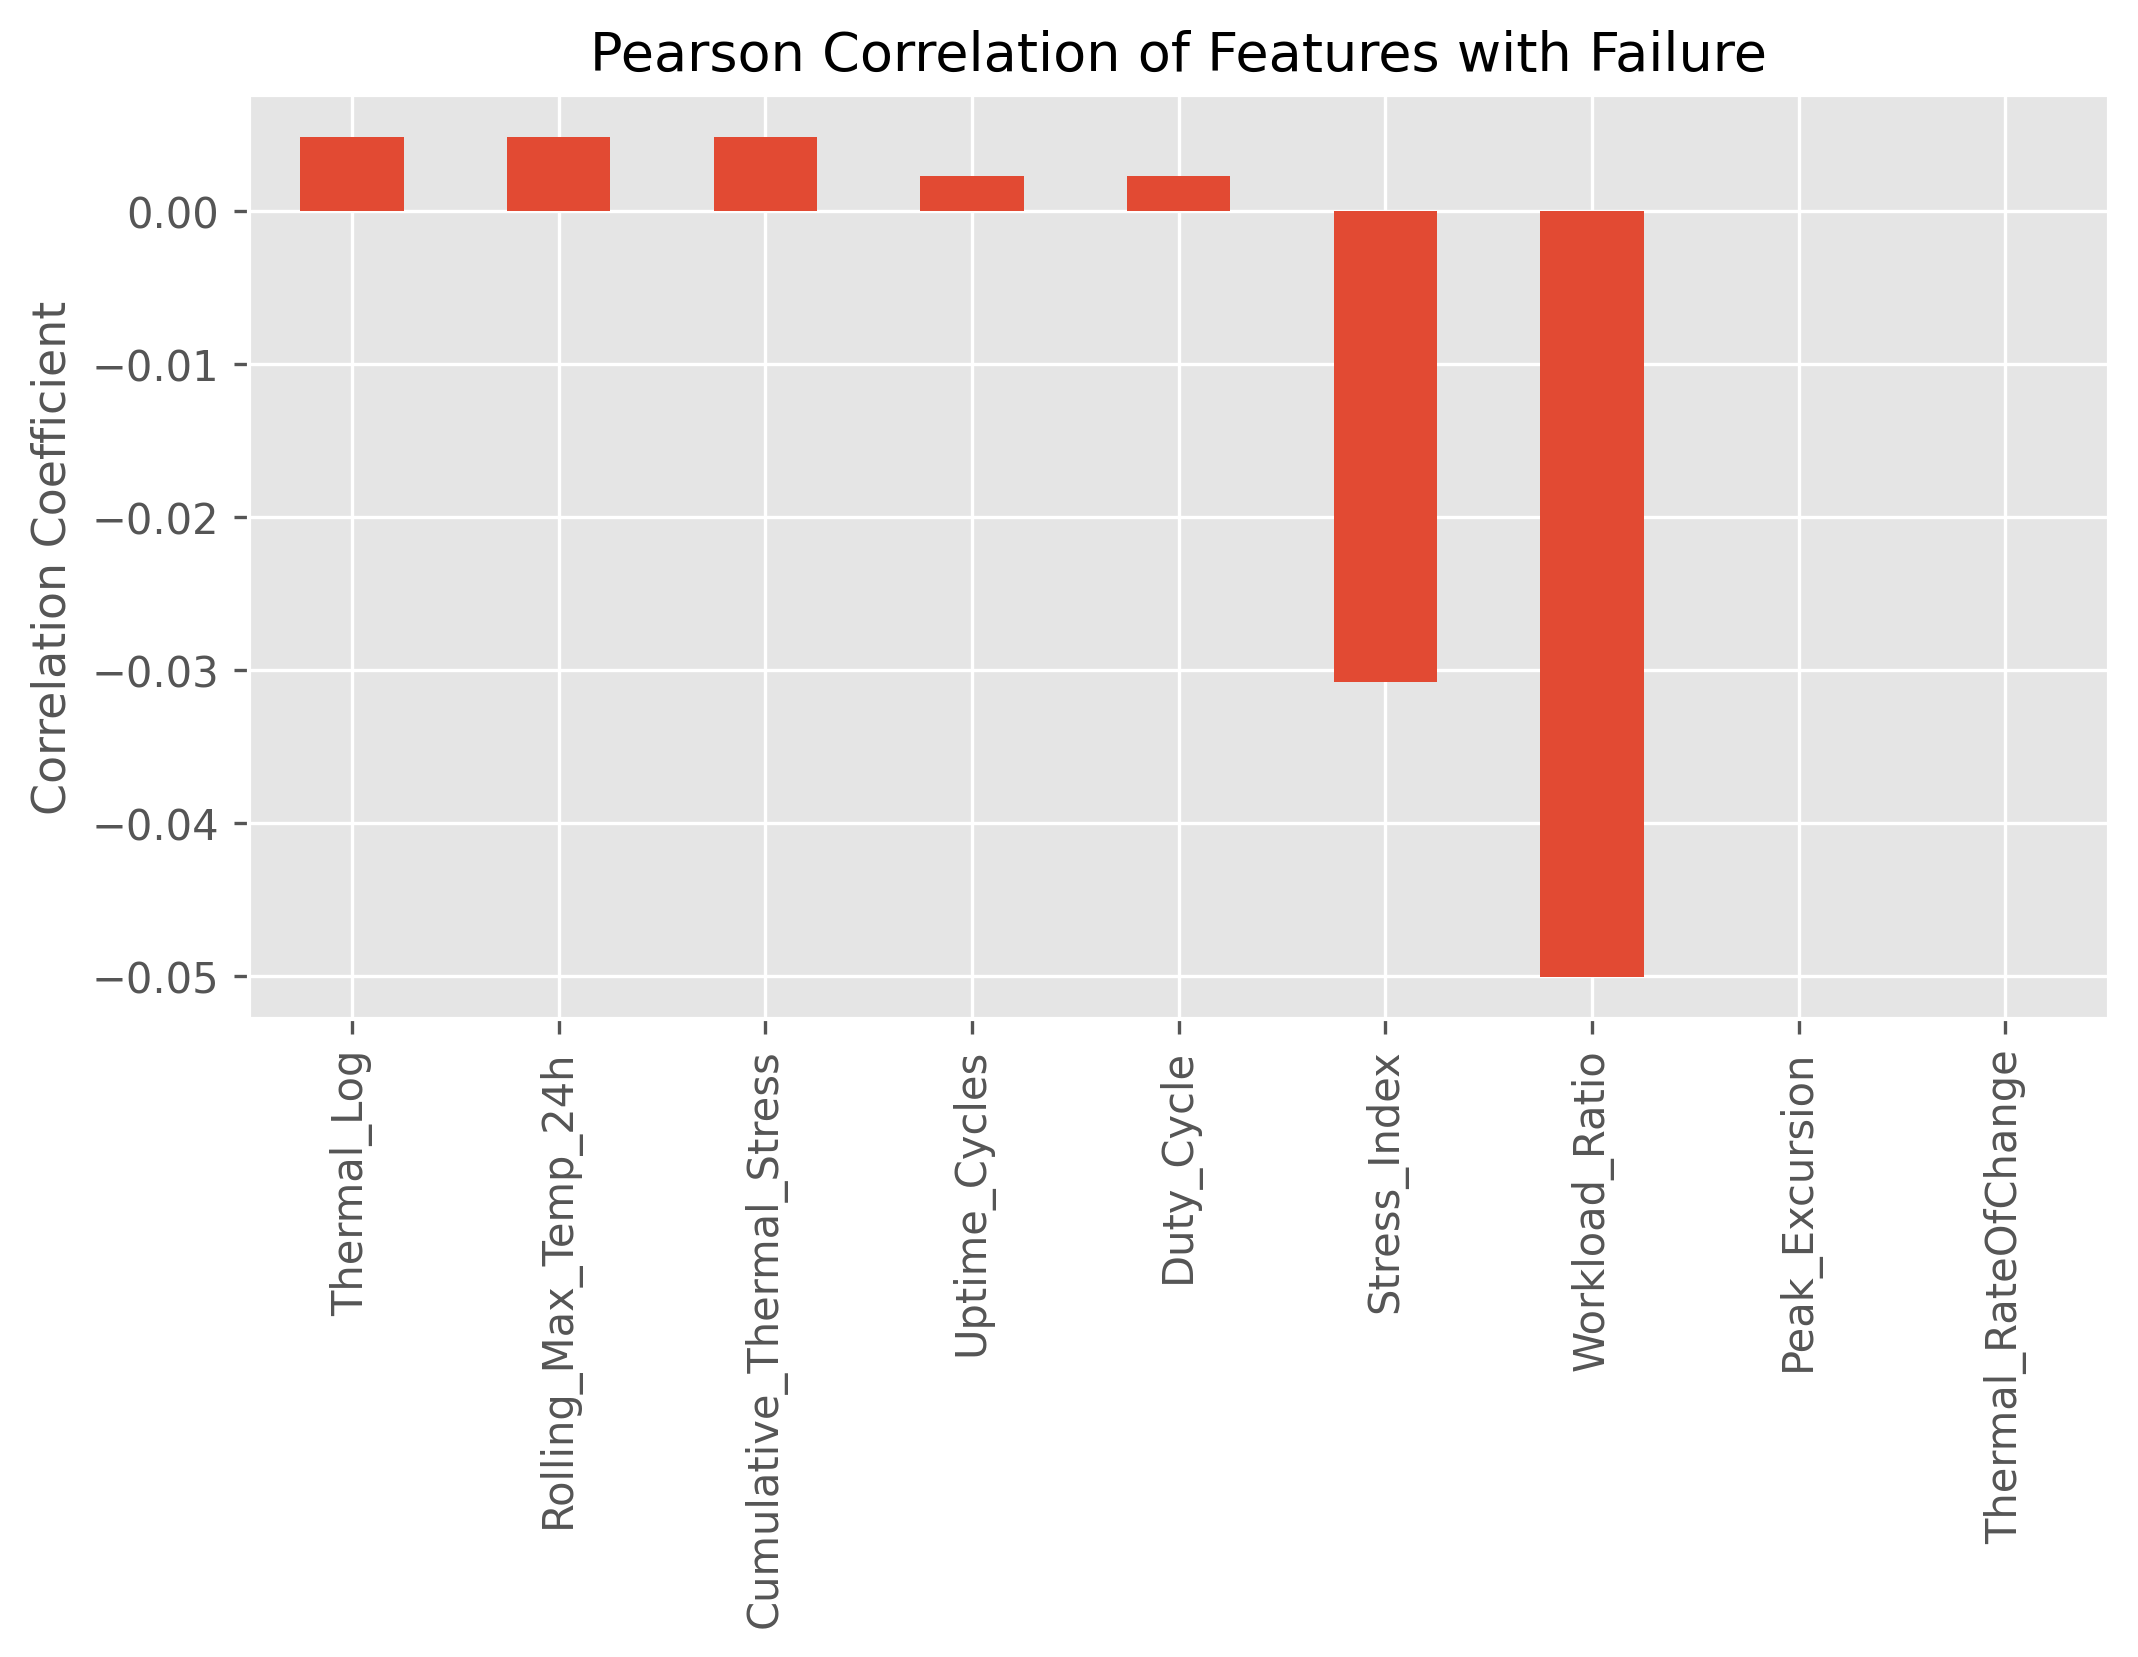

In [5]:
# Pearson Correlation with target
pearson_corr = X.apply(lambda col: col.corr(y)).sort_values(ascending=False)
print("Pearson Correlation with Failure:")
print(pearson_corr)

plt.figure(figsize=(8, 4))
pearson_corr.plot(kind='bar')
plt.title('Pearson Correlation of Features with Failure')
plt.ylabel('Correlation Coefficient')
plt.show()


Random Forest Feature Importances:
Workload_Ratio               0.210088
Stress_Index                 0.173551
Thermal_Log                  0.142203
Rolling_Max_Temp_24h         0.127507
Cumulative_Thermal_Stress    0.126706
Uptime_Cycles                0.114066
Duty_Cycle                   0.105879
Thermal_RateOfChange         0.000000
Peak_Excursion               0.000000
dtype: float64


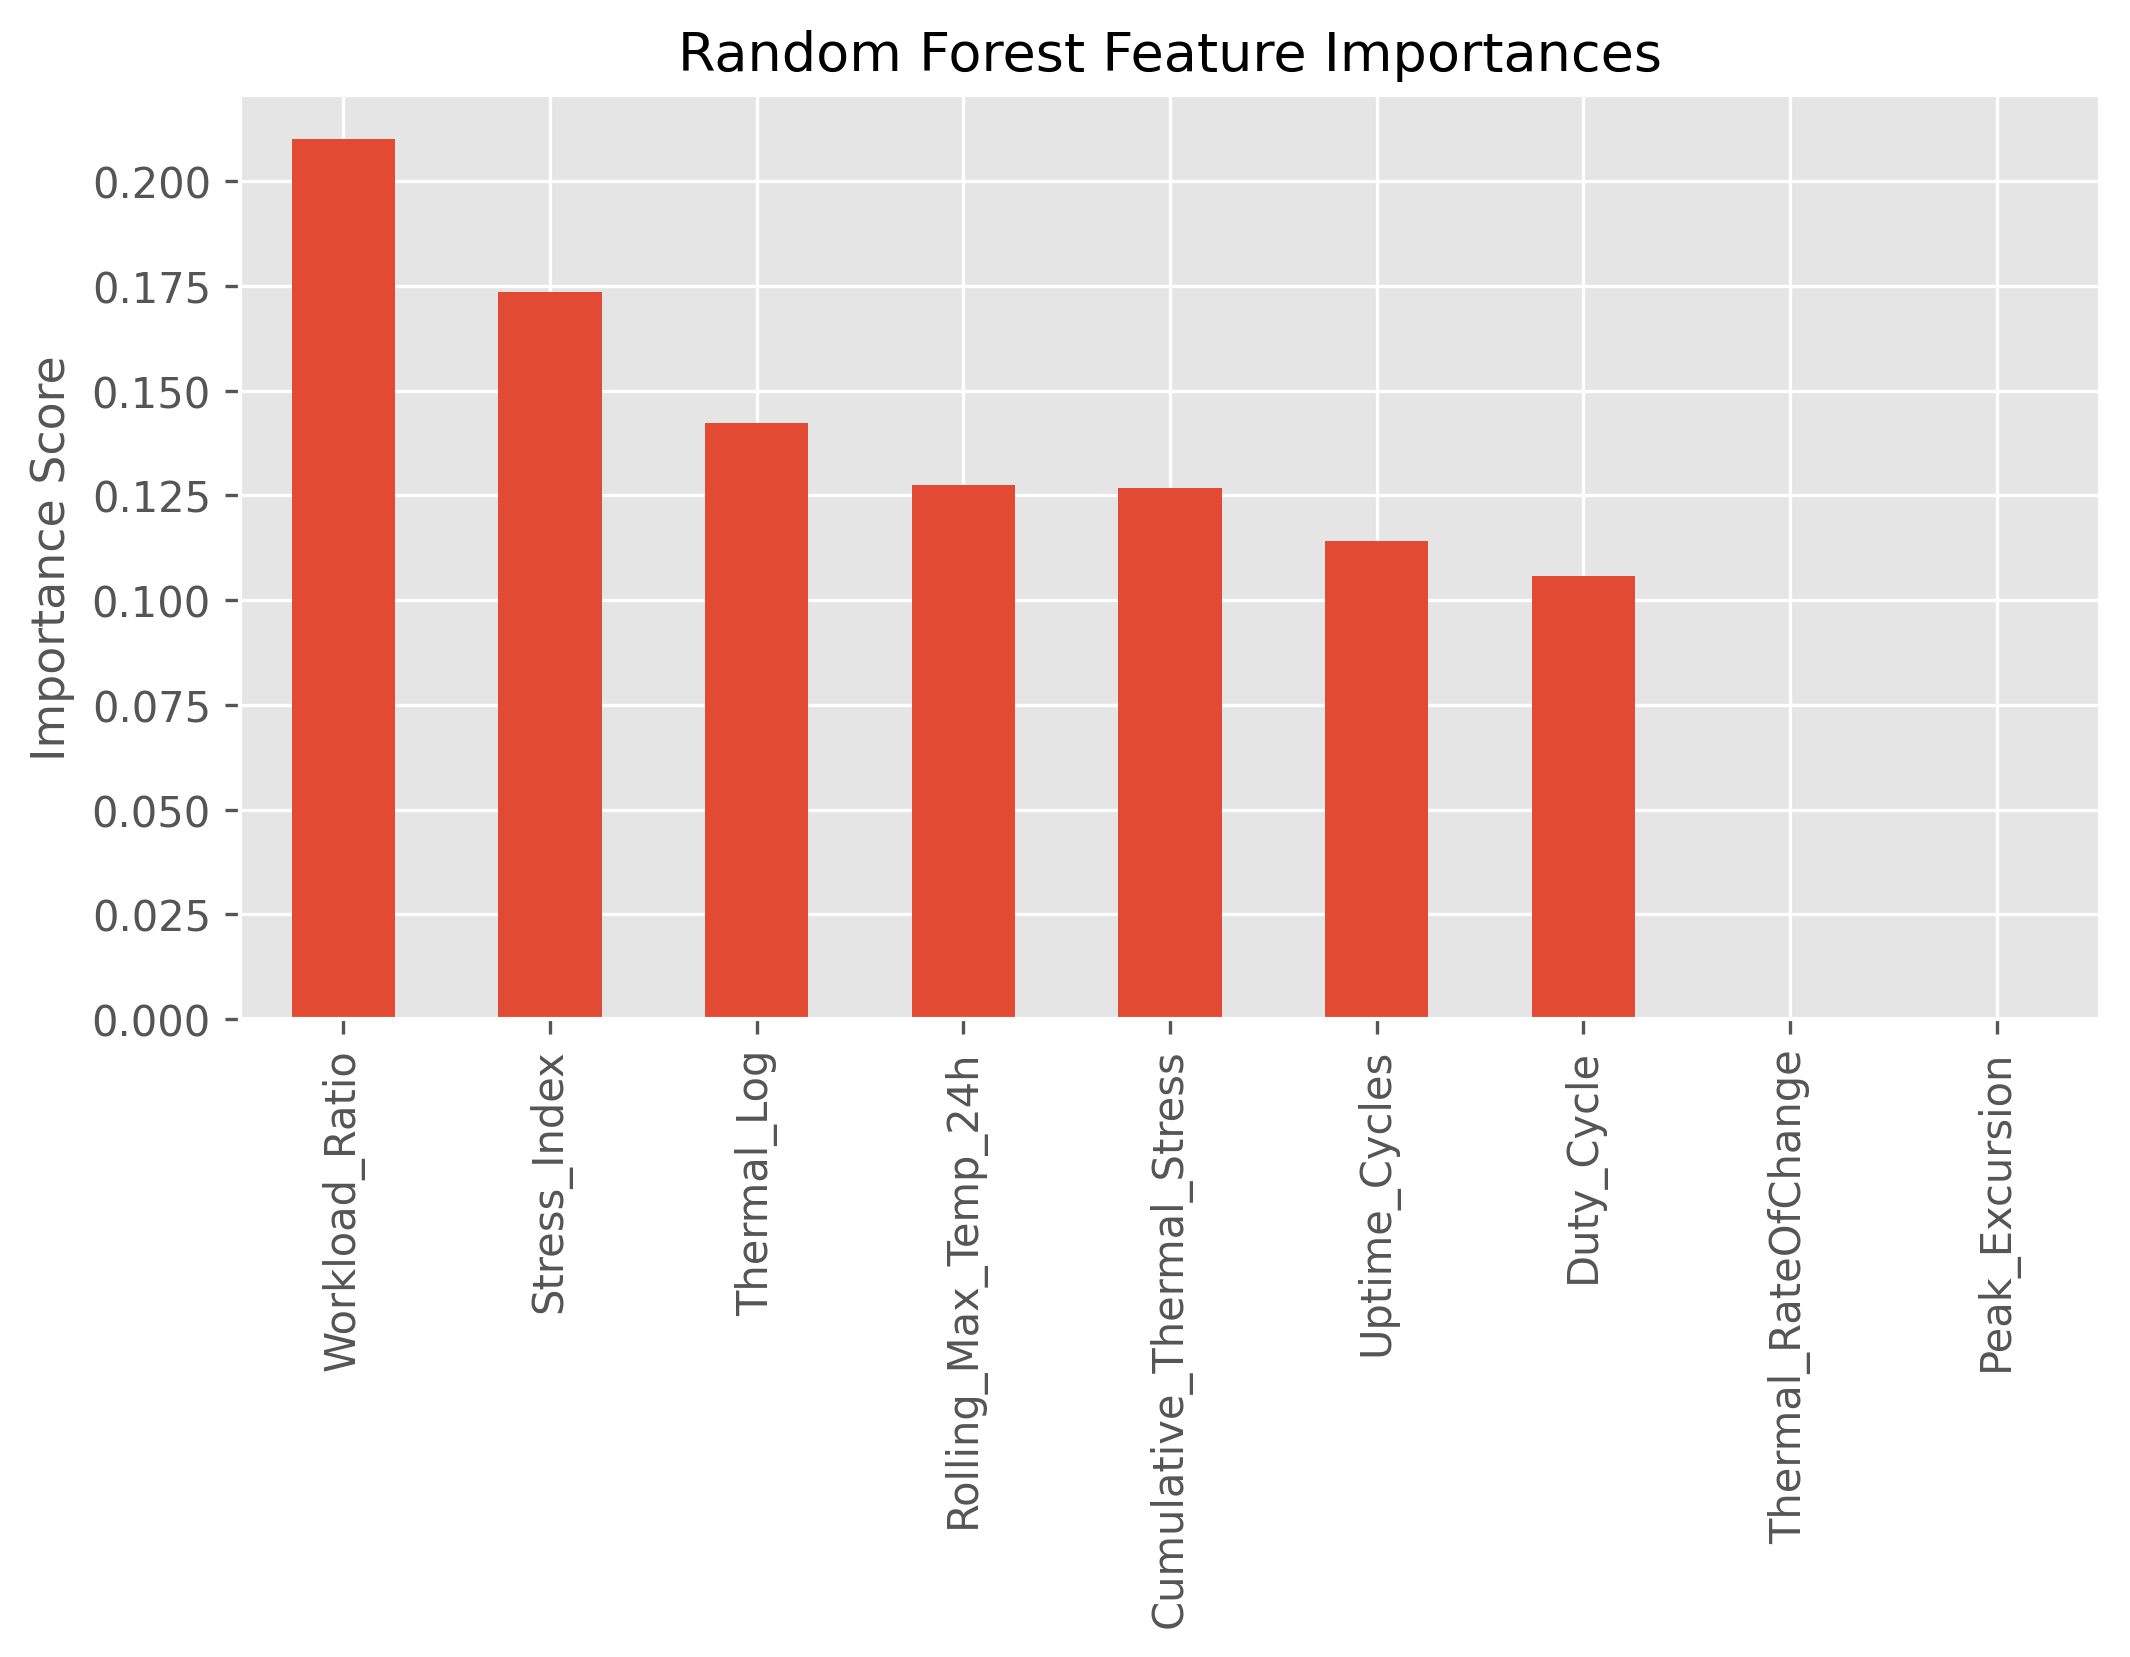

In [6]:
# Random Forest feature_importances_
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf.fit(X, y)

rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Random Forest Feature Importances:")
print(rf_importances)

plt.figure(figsize=(8, 4))
rf_importances.plot(kind='bar')
plt.title('Random Forest Feature Importances')
plt.ylabel('Importance Score')
plt.show()


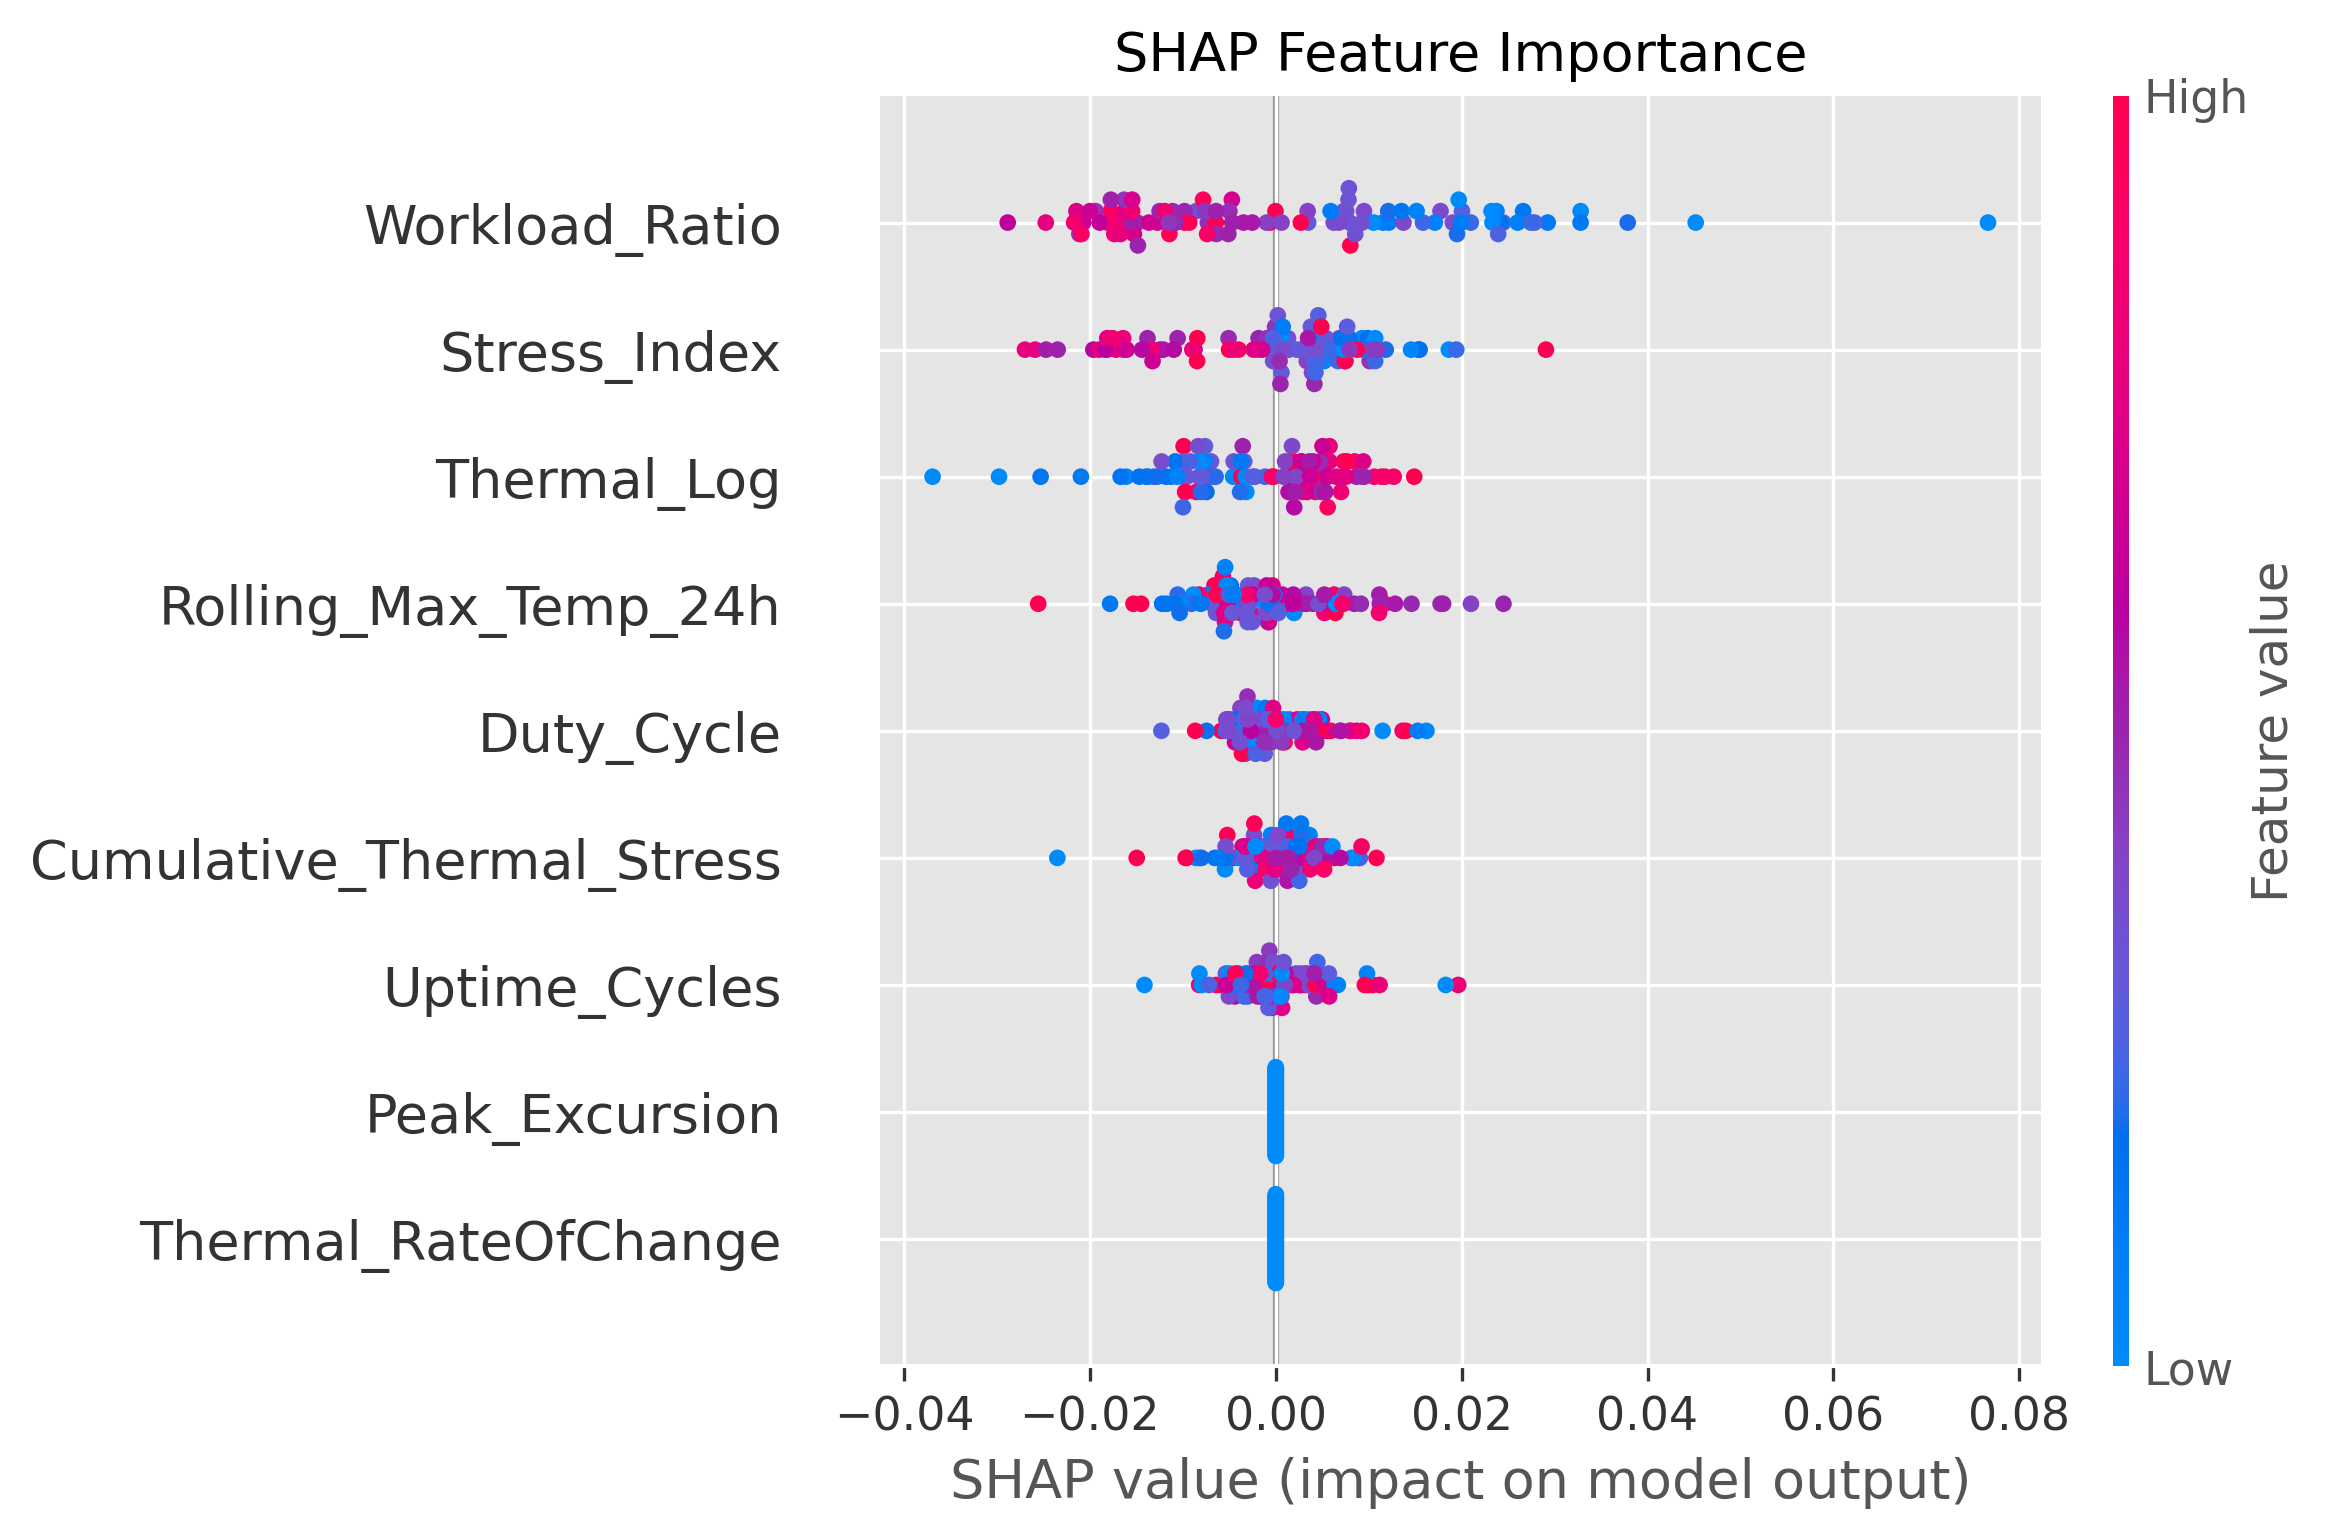

In [7]:
# SHAP Values (using a sample for computational efficiency)
X_sample = shap.sample(X, 100) # Use 100 background samples
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

# Summary plot
plt.figure()
# For RandomForestClassifier, shap_values is a list. We take [1] for the positive class
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_sample, show=False)
else:
    # SHAP >0.40 returns an array for binary classification sometimes
    if len(shap_values.shape) == 3:
        shap.summary_plot(shap_values[:, :, 1], X_sample, show=False)
    else:
        shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Feature Importance')
plt.show()

# Extract mean absolute SHAP values for ranking table
if isinstance(shap_values, list):
    mean_shap = np.abs(shap_values[1]).mean(axis=0)
elif len(shap_values.shape) == 3:
    mean_shap = np.abs(shap_values[:, :, 1]).mean(axis=0)
else:
    mean_shap = np.abs(shap_values).mean(axis=0)

shap_importances = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)


In [8]:
# Ranked Predictor Metric Table
ranking_df = pd.DataFrame({
    'Pearson_Corr': pearson_corr.abs(), # Use absolute for ranking magnitude
    'RF_Importance': rf_importances,
    'SHAP_Importance': shap_importances
})

# Normalize for a combined score
ranking_df = ranking_df / ranking_df.max()
ranking_df['Combined_Score'] = ranking_df.mean(axis=1)
ranking_df = ranking_df.sort_values(by='Combined_Score', ascending=False)

print("Ranked Predictor Metric Table:")
print(ranking_df)

# Save processed and engineered dataset
df.to_csv('../data/processed/dataset_engineered.csv', index=False)
print("Saved engineered dataset to data/processed/dataset_engineered.csv")


Ranked Predictor Metric Table:
                           Pearson_Corr  RF_Importance  SHAP_Importance  \
Workload_Ratio                 1.000000       1.000000         1.000000   
Stress_Index                   0.614639       0.826086         0.557062   
Thermal_Log                    0.096387       0.676877         0.492928   
Rolling_Max_Temp_24h           0.096387       0.606921         0.416337   
Cumulative_Thermal_Stress      0.096387       0.603112         0.250291   
Uptime_Cycles                  0.045926       0.542944         0.243694   
Duty_Cycle                     0.045926       0.503976         0.254625   
Peak_Excursion                      NaN       0.000000         0.000000   
Thermal_RateOfChange                NaN       0.000000         0.000000   

                           Combined_Score  
Workload_Ratio                   1.000000  
Stress_Index                     0.665929  
Thermal_Log                      0.422064  
Rolling_Max_Temp_24h             0.373215 